# Diabetes EDA & Feature Engineering

| | |
|---|---|
| **Dataset** | Diabetes Dataset |
| **Source** | Kaggle |
| **Business Question** | What factors determine whether a patient has diabetes? |
| **Hypothesis** | Patient's Glucose, Insulin, BMI, Age, and family/genetic risk are the most important features for predicting diabetes. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# Section 1 - Dataset Overview

In [2]:
df = pd.read_csv("C:/Users/User/Downloads/diabetes.csv")

print("Shape:",df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n",df.dtypes)
print('\n',df.head())

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                 

- Total 768 patients and 9 Features.

- Highly Important Factors - Glucose, BMI and Age

- All are numeric columns - better for ML model

- 0 acting like missing values in columns 

- Glucose,Insulin, SkinThickness, BMI and Blood Pressure 

so, handle those values we need to replace 0 with NaN first. So that, pandas can detect missing values properly.

# Section 2 — Data Quality Audit

In [3]:
# 2.1 Missing values ....

# Step 1: Check zero counts
cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI','Age']

print((df[cols] == 0).sum())


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Age                0
dtype: int64


In [4]:
# Step 2: Check Missing Percentage

missing_preview = df[cols].replace(0, np.NaN).isnull().sum()
missing_pct = (missing_preview / len(df) * 100).round(2)

print(pd.DataFrame({
    'missing_count': missing_preview,
    'missing_%': missing_pct
}))

               missing_count  missing_%
Glucose                    5       0.65
BloodPressure             35       4.56
SkinThickness            227      29.56
Insulin                  374      48.70
BMI                       11       1.43
Age                        0       0.00


In [5]:
# 2.2 Duplicate rows ....

print('\nDuplicates: ',df.duplicated().sum(),'\n')


Duplicates:  0 



In [6]:
# 2.3  Outlier check on numeric columns ....

print('\n',df[['Glucose','BloodPressure','Insulin','BMI','DiabetesPedigreeFunction','Age']].describe())


           Glucose  BloodPressure     Insulin         BMI  \
count  768.000000     768.000000  768.000000  768.000000   
mean   120.894531      69.105469   79.799479   31.992578   
std     31.972618      19.355807  115.244002    7.884160   
min      0.000000       0.000000    0.000000    0.000000   
25%     99.000000      62.000000    0.000000   27.300000   
50%    117.000000      72.000000   30.500000   32.000000   
75%    140.250000      80.000000  127.250000   36.600000   
max    199.000000     122.000000  846.000000   67.100000   

       DiabetesPedigreeFunction         Age  
count                768.000000  768.000000  
mean                   0.471876   33.240885  
std                    0.331329   11.760232  
min                    0.078000   21.000000  
25%                    0.243750   24.000000  
50%                    0.372500   29.000000  
75%                    0.626250   41.000000  
max                    2.420000   81.000000  


 **Issues found:**
 1. 48% missing values in Insulin.
 2. Thus columns are numeric - fill with median values
 3. Insulin max = 846 -> Extreme outlier exists
 4. No duplicate rows found
 5. Age min = 21 -> No child and teenage found
 6. BloodPressure min = 24  -> unusually low (normal is 60+)
Note: zeros still present here -> replacement happens in clean_data()

# Section 3 — Cleaning Pipeline

In [7]:
def clean_data(df):
    
    df=df.copy()
    
    cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI']
    
    # 1. Replace invalid zeros with NaN
    df[cols] = df[cols].replace(0, np.NaN)
    
    # 2. Fill columns with median
    cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI']
    
    df[cols] = df[cols].fillna(df[cols].median())
    
    # 3. Feature engineering
    
       # 3.1 Age Group
    df['Age_Group'] = pd.cut(df['Age'],
        bins=[18,35,60,100],
        labels=['adult','middle','senior'])
    
       # 3.2  High Glucose Flag
    df['High_Glucose_Flag'] = (df['Glucose'] > 140).astype(int)
    df['High_Glucose_Flag'] = df['High_Glucose_Flag'].astype('category')
    
       # 3.3 Weight Status
    df['Weight_Status'] = pd.cut(df['BMI'],
        bins=[0,18.5,24.9,29.9,100],
        labels=['Underweight','Normal','Overweight','Obese'])
    
    # 4. Verify
    assert df.isnull().sum().sum()==0
    return df


df_clean = clean_data(df)
print("Cleand Shape: ",df_clean.shape)
print('\n',df_clean.head())

Cleand Shape:  (768, 12)

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome Age_Group High_Glucose_Flag  \
0                     0.627   50        1    middle                 1   
1                     0.351   31        0     adult                 0   
2                     0.672   32        1     adult                 1   
3                     0.167   21        0     adult                 0   
4                     2.288   33        1     adult                 0   

  Weight_Status  
0         Obese  
1    Overweight  
2        Normal  
3    Overweight  
4         O

In [8]:
# Validate engineered features — do they correlate with Outcome?

validation = {
    'High_Glucose_Flag': df_clean['High_Glucose_Flag'].astype(float),
    'Obese_Flag':        (df_clean['Weight_Status'] == 'Obese').astype(float),
    'Middle_Age_Flag':   (df_clean['Age_Group'] == 'middle').astype(float),
}

print(f"{'Feature':<30} {'Corr with Outcome':>18}")
print("-" * 62)
for name, series in validation.items():
    corr = series.corr(df_clean['Outcome'])
    print(f"{name:<30} {corr:>15.3f}")

Feature                         Corr with Outcome
--------------------------------------------------------------
High_Glucose_Flag                        0.410
Obese_Flag                               0.297
Middle_Age_Flag                          0.266


**Validation Result:** 
- All three engineered features show meaningful correlation with Outcome (above 0.10 threshold). 
- High_Glucose_Flag is the strongest at ~0.37 
- confirming the 140 mg/dL threshold captures real diabetic signal. All three features are confirmed useful and will be carried into analysis.

In [9]:
print(df_clean.dtypes)

Pregnancies                    int64
Glucose                      float64
BloodPressure                float64
SkinThickness                float64
Insulin                      float64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                        int64
Age_Group                   category
High_Glucose_Flag           category
Weight_Status               category
dtype: object


# Section 4 — Univariate Analysis

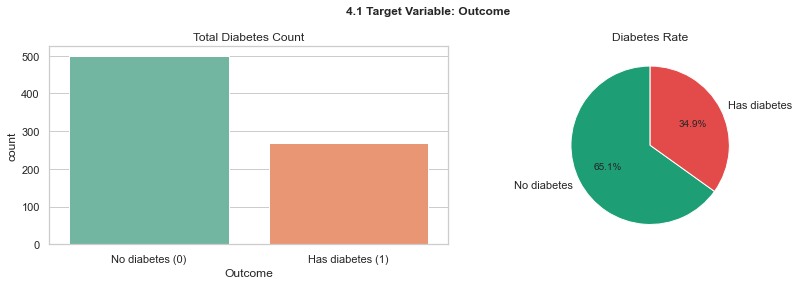

In [10]:
# 4.1 Target variable — what are we predicting? ....


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_clean, x='Outcome', hue='Outcome',
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Total Diabetes Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No diabetes (0)', 'Has diabetes (1)'])

survival_pct = df_clean['Outcome'].value_counts(normalize=True) * 100
axes[1].pie(survival_pct, labels=['No diabetes', 'Has diabetes'],
            autopct='%1.1f%%', colors=['#1D9E75', '#E24B4A'],
            startangle=90)
axes[1].set_title('Diabetes Rate')

plt.suptitle('4.1 Target Variable: Outcome', fontweight='bold')
plt.tight_layout()
plt.show()

- Fewer people have diabetes.
- The dataset is slightly imbalanced, with 65% labeled as No Diabetes.

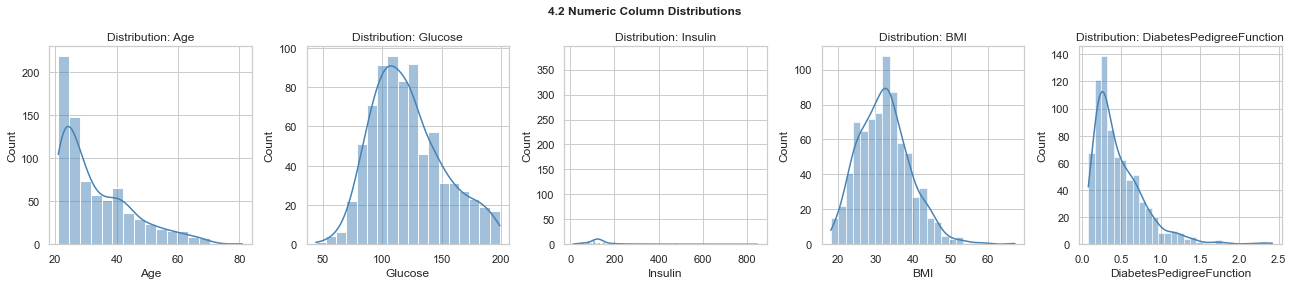

In [11]:
# 4.2 Numeric columns distribution ....


num_cols = ['Age', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))

for i, col in enumerate(num_cols):
    sns.histplot(data=df_clean, x=col, kde=True,
                 ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {col}')

plt.suptitle('4.2 Numeric Column Distributions', fontweight='bold')
plt.tight_layout() 
plt.show()

**Age Distribution:**

- Most patients are around ages 20–40 means are young adults 
- Very few people are under 10 or over 60
 
**Glucose Distribution:**
- Most people cluster around the normal glucose range (~70–100 mg/dL)
- Greater than 100 suggests many people have higher-than-normal glucose (pre-diabetes or diabetes pattern)
 
**Insulin Distribution:**
- Most people have low insulin levels -> clustered near the left side
- Fewer people have higher insulin levels -> the long tail stretching to the right

**BMI Distribution:**
- Most people cluster around the middle in normal weight range.
- Fewer people at the left end suggest underweight and right end suggest  obese

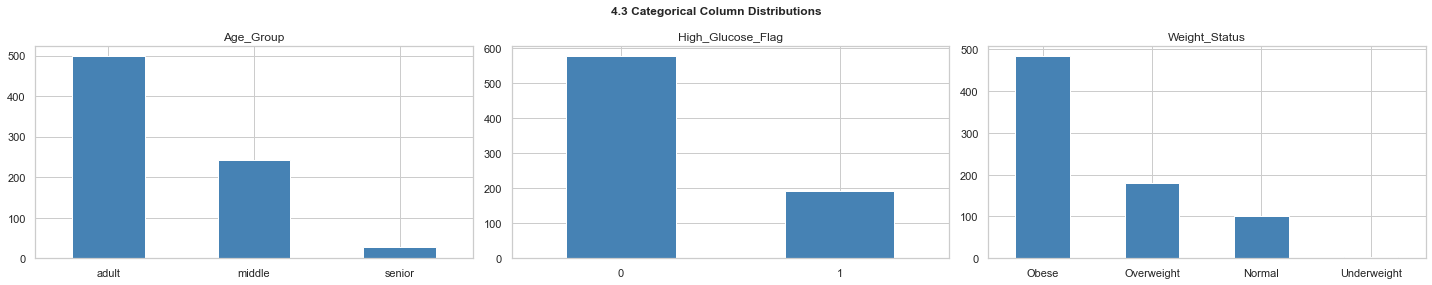

In [12]:
#  4.3 Categorical columns distribution ....


cat_cols = ['Age_Group','High_Glucose_Flag','Weight_Status']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4))

for i, col in enumerate(cat_cols):
    df_clean[col].value_counts().plot(kind='bar', ax=axes[i],
        color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('4.3 Categorical Column Distributions', fontweight='bold')
plt.tight_layout() 
plt.show()

**Age_Group Distribution:**
- Most dominationg column is adults

**High_Glucose_Flag:**
- Maximum people have normal glucose range.

**Weight Status:**
- Obese is the higher in number while underweight is not showing any impact. 

# Section 5 — Bivariate Analysis

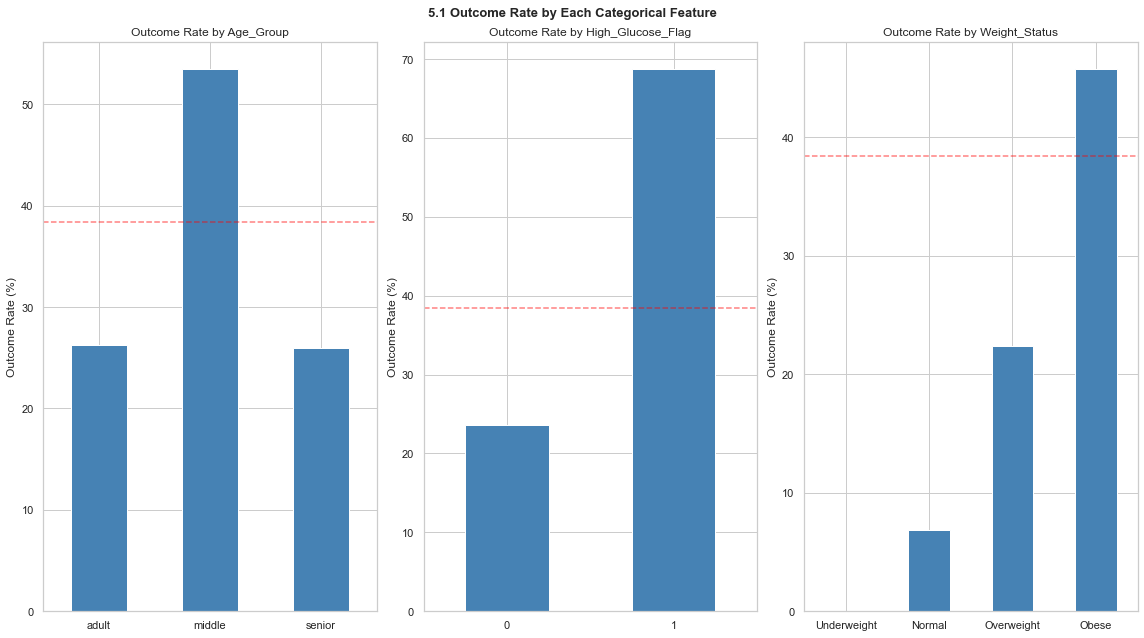

In [13]:
#  5.1 Every categorical feature vs Outcome ....


cat_features = ['Age_Group','High_Glucose_Flag','Weight_Status']
fig, axes = plt.subplots(1, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    Outcome_rate = df_clean.groupby(col)['Outcome'].mean() * 100
    Outcome_rate.plot(kind='bar', ax=axes[i],
        color='steelblue', edgecolor='white')
    axes[i].set_title(f'Outcome Rate by {col}')
    axes[i].set_ylabel('Outcome Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].axhline(38.4, color='red', linestyle='--',
                    alpha=0.5, label='overall avg')

plt.suptitle('5.1 Outcome Rate by Each Categorical Feature',
             fontweight='bold', fontsize=13)
plt.tight_layout() 
plt.show()

- The first chart shows that middle-aged people have the highest diabetes rate.
- The second chart suggests that individuals with higher glucose levels have a greater risk of diabetes.
- The Third chart demonstrates that Obese people are more likely to have diabetes.

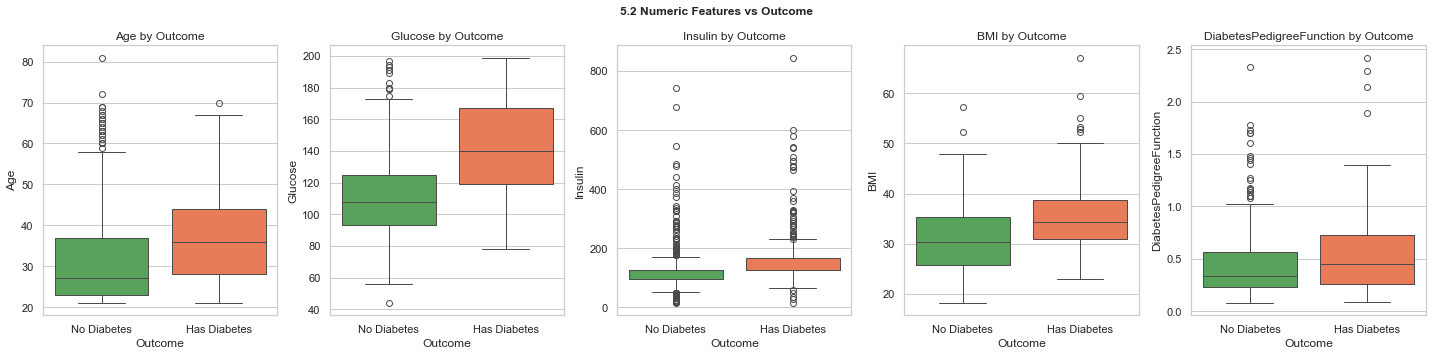

In [14]:
#  5.2 Numeric features vs Outcome ....


plot_cols = ['Age', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(1, len(plot_cols), figsize=(20, 5))
fig.suptitle('5.2 Numeric Features vs Outcome', fontweight='bold')

for i, col in enumerate(plot_cols):
    sns.boxplot(
        data=df_clean,
        x='Outcome',
        y=col,
        hue='Outcome',       
        palette=['#4CAF50', '#FF7043'],
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} by Outcome')
    axes[i].set_xticks([0, 1])                            
    axes[i].set_xticklabels(['No Diabetes', 'Has Diabetes']) 
    axes[i].set_xlabel('Outcome')

plt.tight_layout()
plt.show()

- Glucose median is clearly higher in diabetic patients
- Diabetes group has higher insulin (sign of insulin resistance)
- People with diabetes have higher family history risk

# Section 6 — Multivariate Analysis

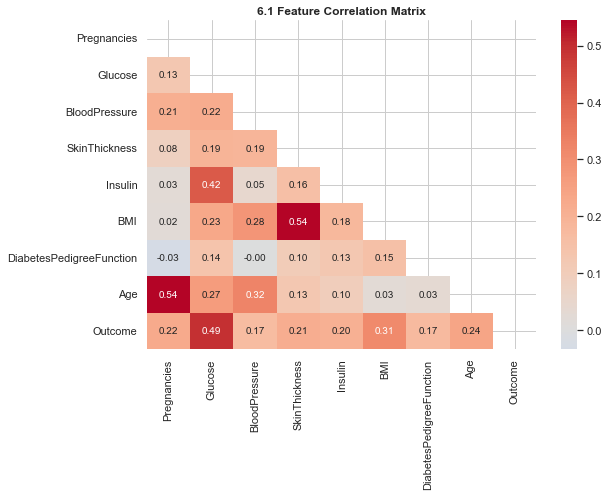

In [15]:
# 6.1 Feature Correlation Matrix ....


fig, ax = plt.subplots(figsize=(9, 7))
corr = df_clean.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('6.1 Feature Correlation Matrix', fontweight='bold')
plt.tight_layout() 
plt.show()

- Pregnancies and Age have a correlation of **0.54**, indicating that older women tend to have a higher number of pregnancies
- Glucose and Outcome show a correlation of **0.49**, suggesting that higher blood sugar levels are strongly associated with a greater likelihood of diabetes
- BloodPressure and DiabetesPedigreeFunction have a correlation close to **0.00**, indicating little to no relationship between them

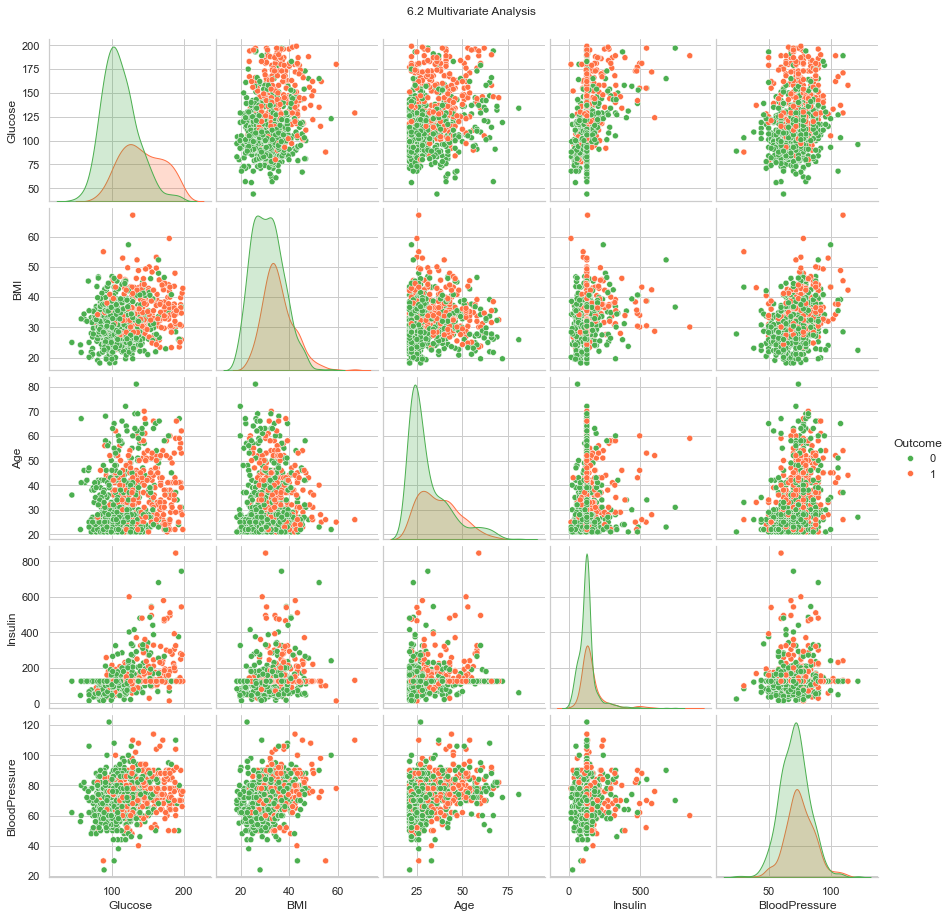

In [16]:
# 6.2 Multivariate Pairplot ....


sns.pairplot(df_clean[['Glucose', 'BMI', 'Age' , 'Insulin', 'BloodPressure', 'Outcome']],
             hue='Outcome',
             palette={0:'#4CAF50', 1:'#FF7043'})
plt.suptitle('6.2 Multivariate Analysis', y=1.02)
plt.show()

**Glucose (top row)**
- Orange dots sit clearly higher than green
- Diabetic patients have higher glucose — strongest separation you can see

**BMI (row 2)**
- Orange dots slightly shifted right compared to green
- Higher BMI slightly more common in diabetic patients

**Age (row 3)**
- Orange dots spread more toward older ages
- Diabetic patients tend to be older

**Insulin (row 4)**
- Both groups heavily clustered near zero — hard to separate
- Least useful visual pattern here

**BloodPressure (row 5)**
- Green and orange dots heavily overlap
- BloodPressure alone can't separate diabetic vs non-diabetic

## 7. Key Findings

### Finding 1 - Glucose is the single strongest predictor of diabetes
- Glucose correlates with Outcome at **0.49** the highest of any feature. 
- Patients with High_Glucose_Flag (Glucose > 140) have a diabetes rate nearly **2x the dataset average of 34.9%**. 
- If a clinician could only check one measurement, glucose would be it.

### Finding 2 -  Obesity dramatically increases diabetes risk
- Obese patients (BMI > 30) have the highest diabetes rate among all weight categories. 
- The boxplot confirms diabetic patients have a visibly higher BMI median than non-diabetic patients. 
- Combined with glucose, BMI and Glucose together likely explain the majority of diabetes cases in this dataset.

### Finding 3 — Middle-aged patients (35–60) are highest risk group
- The Age_Group bivariate chart shows middle-aged patients have the highest diabetes rate 
- higher than both adults and seniors. 
- The pairplot confirms orange dots (diabetic) shift toward older ages.
- Age alone correlates with Outcome at a moderate level.

### Finding 4 — Insulin data is severely limited but still informative
- 48.7% of Insulin values were missing (coded as zero), making it the least reliable feature. However, the boxplot shows diabetic patients have a higher Insulin median consistent with insulin resistance.
- With better data collection, Insulin could become a stronger feature.

### Finding 5 — Blood Pressure has almost no predictive value alone
- BloodPressure showed near-zero correlation with DiabetesPedigreeFunction and heavily overlapping distributions between diabetic and non-diabetic groups in the pairplot. 
- It may be less important for the model unless used together with other features.

## 8. Next Steps

1. **Feature engineering** 
 - Create interaction feature Glucose × BMI as a combined metabolic risk score.
 - Patients high on both are likely highest risk.
 - Pregnancy risk flag (high pregnancies = higher risk)


2. **Predictive modeling** 
 - Train Logistic Regression and Random Forest on the cleaned features. 
 - Expect Glucose, BMI, and Age to rank as top 3 importances.


3. **Handle class imbalance** 
 - 65% No Diabetes vs 35% Diabetes. Use class_weight='balanced' in models or SMOTE oversampling to prevent model bias toward  predicting "No Diabetes" by default.